# Dimensionality Reduction & Unsupervised Clustering

## Objective

Apply Principal Component Analysis (PCA) and unsupervised clustering algorithms to discover patterns in high-dimensional numerical data.

### Methods
- Standardization
- PCA
- Explained Variance Ratio
- Scree Plot
- K-Means
- Elbow Method
- Silhouette Score
- DBSCAN
- Hierarchical Clustering
- 2D PCA Cluster Visualizations

**Data note:** This implementation uses a clearly labeled synthetic dataset because no real dataset was provided. The results demonstrate the methodology and reproducibility of the workflow rather than real-world findings.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import make_blobs
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.metrics import silhouette_score

np.random.seed(42)

X, true_labels = make_blobs(
    n_samples=600,
    n_features=10,
    centers=4,
    cluster_std=2.0,
    random_state=42
)

feature_names = [f"Feature_{i+1}" for i in range(10)]

df = pd.DataFrame(X, columns=feature_names)

print("Dataset shape:", df.shape)
display(df.head())


Dataset shape: (600, 10)


,Feature_1,Feature_2,Feature_3,Feature_4,Feature_5,Feature_6,Feature_7,Feature_8,Feature_9,Feature_10
0,-1.799918,-6.919995,-2.570756,-2.916877,-1.794297,5.384795,-6.747690,-2.411405,0.418930,-8.028432
1,-3.194573,8.271404,1.824855,0.417536,-9.100779,-3.375569,-6.966971,9.866633,3.465644,1.903348
2,-0.192006,7.372921,6.566631,2.798732,-5.235507,-3.086524,-9.329104,5.816051,0.243271,2.529831
3,-5.577426,11.569640,5.304507,0.476197,-3.777323,-6.648760,-6.479733,7.458560,6.143796,7.672133
4,0.717750,-4.970329,-7.637180,10.693989,9.066368,7.373107,-4.799025,-3.938920,2.059569,3.013645


## 1. Standardize High-Dimensional Numerical Features

In [2]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)

scaled_df = pd.DataFrame(
    X_scaled,
    columns=feature_names
)

display(scaled_df.describe().round(3))


,Feature_1,Feature_2,Feature_3,Feature_4,Feature_5,Feature_6,Feature_7,Feature_8,Feature_9,Feature_10
count,600.000,600.000,600.000,600.000,600.000,600.000,600.000,600.000,600.000,600.000
mean,0.000,0.000,0.000,-0.000,-0.000,0.000,0.000,-0.000,0.000,-0.000
std,1.001,1.001,1.001,1.001,1.001,1.001,1.001,1.001,1.001,1.001
min,-2.376,-1.665,-1.981,-1.868,-1.603,-1.811,-3.137,-2.482,-3.148,-2.221
25%,-0.728,-0.945,-0.933,-0.822,-0.805,-0.949,-0.733,-0.715,-0.676,-0.726
50%,0.242,0.093,0.042,-0.180,-0.316,0.051,0.081,0.049,0.080,-0.011
75%,0.804,0.972,0.909,0.830,0.879,0.962,0.754,0.709,0.664,0.758
max,1.986,1.571,1.846,2.307,2.449,1.934,2.656,2.536,3.139,2.240


## 2. Principal Component Analysis (PCA)

In [3]:
pca_full = PCA()
X_pca_full = pca_full.fit_transform(X_scaled)

explained_variance = pca_full.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance)

variance_table = pd.DataFrame({
    "Principal Component": np.arange(1, 11),
    "Explained Variance Ratio": explained_variance,
    "Cumulative Variance": cumulative_variance
})

display(variance_table.round(4))

n_components_90 = np.argmax(
    cumulative_variance >= 0.90
) + 1

print(
    "Components required for at least 90% variance:",
    n_components_90
)


,Principal Component,Explained Variance Ratio,Cumulative Variance
0,1,0.5563,0.5563
1,2,0.2018,0.7581
2,3,0.1153,0.8734
3,4,0.0448,0.9182
4,5,0.0312,0.9494
5,6,0.0143,0.9638
6,7,0.0107,0.9744
7,8,0.0099,0.9843
8,9,0.0089,0.9932
9,10,0.0068,1.0000


Components required for at least 90% variance: 4


## 3. PCA Scree Plot

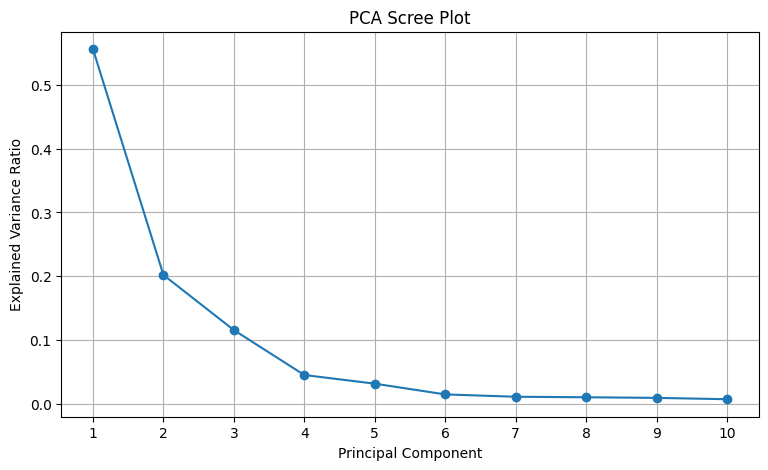

In [4]:
plt.figure(figsize=(9,5))

plt.plot(
    range(1, 11),
    explained_variance,
    marker="o"
)

plt.xlabel("Principal Component")
plt.ylabel("Explained Variance Ratio")
plt.title("PCA Scree Plot")
plt.xticks(range(1, 11))
plt.grid(True)
plt.show()


## 4. Cumulative Explained Variance

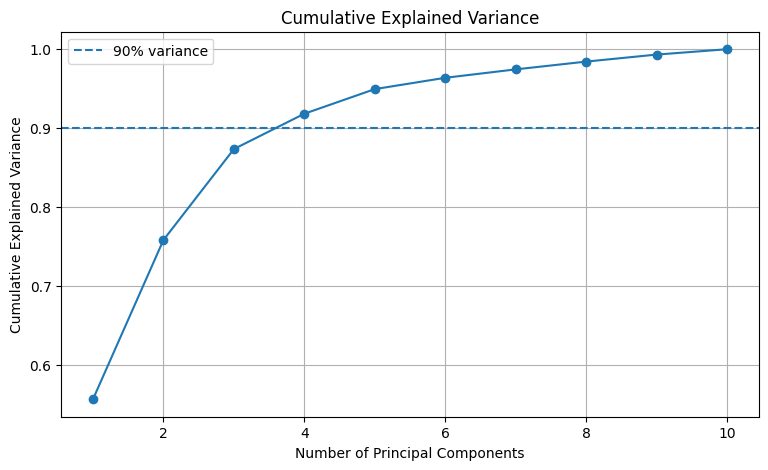

In [5]:
plt.figure(figsize=(9,5))

plt.plot(
    range(1, 11),
    cumulative_variance,
    marker="o"
)

plt.axhline(
    0.90,
    linestyle="--",
    label="90% variance"
)

plt.xlabel("Number of Principal Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("Cumulative Explained Variance")
plt.legend()
plt.grid(True)
plt.show()


## 5. Two-Dimensional PCA Projection

In [6]:
pca_2 = PCA(n_components=2)

X_pca = pca_2.fit_transform(X_scaled)

pca_df = pd.DataFrame(
    X_pca,
    columns=["PC1", "PC2"]
)

print(
    "PC1 variance:",
    round(pca_2.explained_variance_ratio_[0], 4)
)

print(
    "PC2 variance:",
    round(pca_2.explained_variance_ratio_[1], 4)
)

print(
    "Total 2D variance:",
    round(pca_2.explained_variance_ratio_.sum(), 4)
)


PC1 variance: 0.5563
PC2 variance: 0.2018
Total 2D variance: 0.7581


## 6. K-Means — Elbow Method

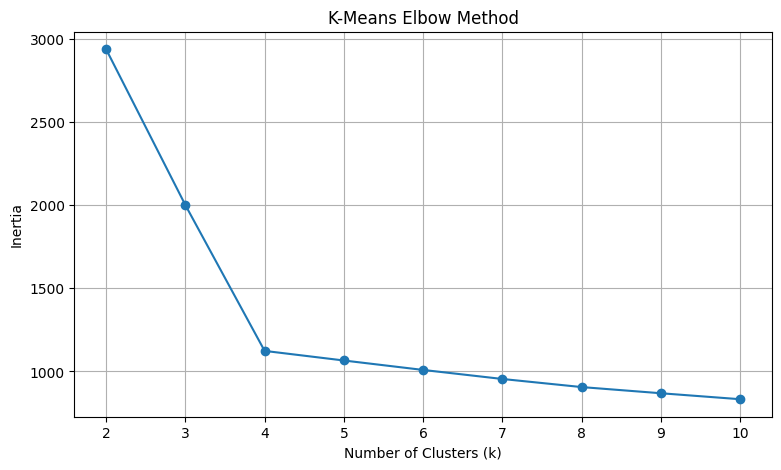

In [7]:
inertias = []

k_values = range(2, 11)

for k in k_values:

    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    model.fit(X_scaled)

    inertias.append(model.inertia_)

plt.figure(figsize=(9,5))

plt.plot(
    k_values,
    inertias,
    marker="o"
)

plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia")
plt.title("K-Means Elbow Method")
plt.grid(True)
plt.show()


## 7. K-Means — Silhouette Score Analysis

In [8]:
silhouette_results = []

for k in range(2, 11):

    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = model.fit_predict(X_scaled)

    score = silhouette_score(
        X_scaled,
        labels
    )

    silhouette_results.append(score)

silhouette_table = pd.DataFrame({
    "k": range(2, 11),
    "Silhouette Score": silhouette_results
})

display(
    silhouette_table.round(4)
)

best_k = int(
    silhouette_table.loc[
        silhouette_table["Silhouette Score"].idxmax(),
        "k"
    ]
)

print(
    "Best k according to silhouette score:",
    best_k
)


,k,Silhouette Score
0,2,0.4626
1,3,0.4829
2,4,0.5197
3,5,0.4349
4,6,0.3356
5,7,0.2521
6,8,0.1649
7,9,0.1648
8,10,0.1637


Best k according to silhouette score: 4


In [9]:
kmeans = KMeans(
    n_clusters=best_k,
    random_state=42,
    n_init=10
)

kmeans_labels = kmeans.fit_predict(X_scaled)

kmeans_score = silhouette_score(
    X_scaled,
    kmeans_labels
)

print(
    "K-Means silhouette score:",
    round(kmeans_score, 4)
)


K-Means silhouette score: 0.5197


## 8. K-Means Cluster Visualization

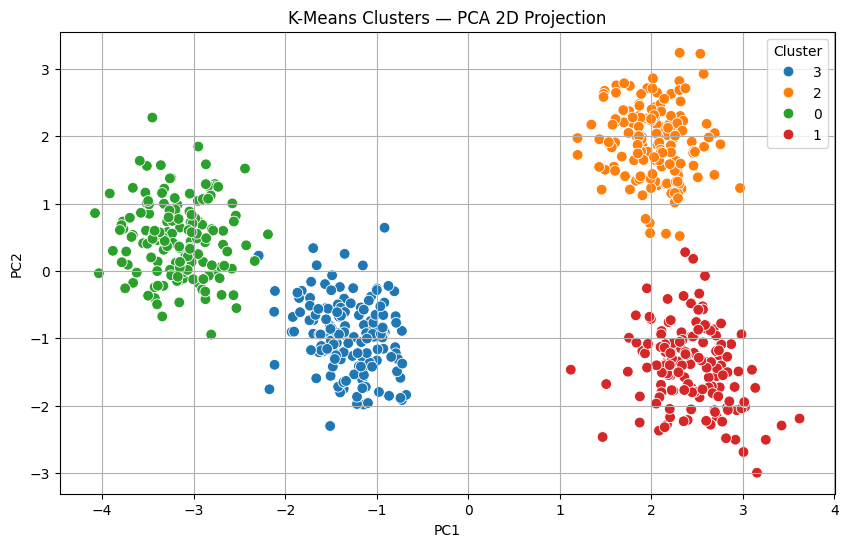

In [10]:
plot_kmeans = pca_df.copy()

plot_kmeans["Cluster"] = (
    kmeans_labels.astype(str)
)

plt.figure(figsize=(10,6))

sns.scatterplot(
    data=plot_kmeans,
    x="PC1",
    y="PC2",
    hue="Cluster",
    palette="tab10",
    s=60
)

plt.title(
    "K-Means Clusters — PCA 2D Projection"
)

plt.grid(True)
plt.show()


## 9. DBSCAN Clustering

In [11]:
dbscan = DBSCAN(
    eps=1.2,
    min_samples=8
)

dbscan_labels = dbscan.fit_predict(X_scaled)

n_dbscan_clusters = (
    len(set(dbscan_labels))
    - (1 if -1 in dbscan_labels else 0)
)

n_noise = int(
    np.sum(dbscan_labels == -1)
)

print(
    "DBSCAN clusters:",
    n_dbscan_clusters
)

print(
    "DBSCAN noise points:",
    n_noise
)

valid_dbscan = dbscan_labels != -1

if (
    valid_dbscan.sum() > 1
    and len(set(dbscan_labels[valid_dbscan])) >= 2
):

    dbscan_silhouette = silhouette_score(
        X_scaled[valid_dbscan],
        dbscan_labels[valid_dbscan]
    )

    print(
        "DBSCAN silhouette score:",
        round(dbscan_silhouette, 4)
    )

else:

    dbscan_silhouette = None

    print(
        "DBSCAN silhouette score: Not available"
    )


DBSCAN clusters: 4
DBSCAN noise points: 47
DBSCAN silhouette score: 0.5411


## 10. DBSCAN Cluster Visualization

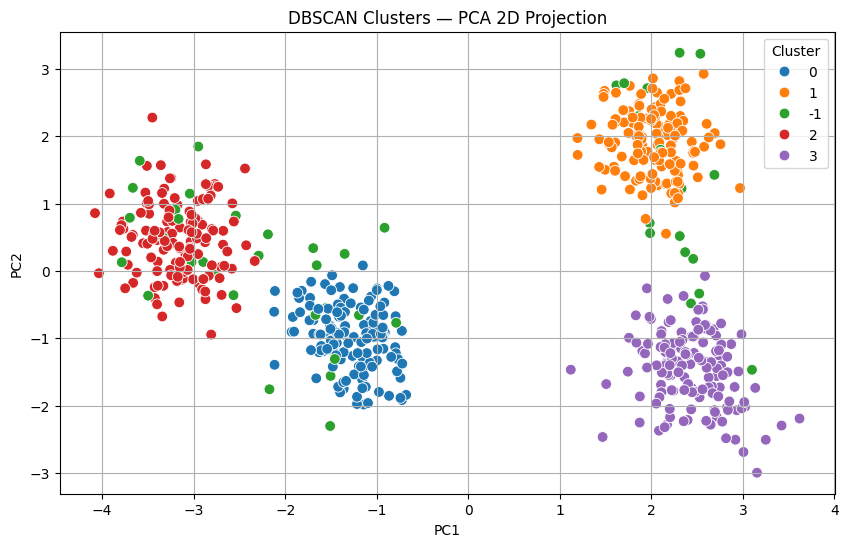

In [12]:
plot_dbscan = pca_df.copy()

plot_dbscan["Cluster"] = (
    dbscan_labels.astype(str)
)

plt.figure(figsize=(10,6))

sns.scatterplot(
    data=plot_dbscan,
    x="PC1",
    y="PC2",
    hue="Cluster",
    palette="tab10",
    s=60
)

plt.title(
    "DBSCAN Clusters — PCA 2D Projection"
)

plt.grid(True)
plt.show()


## 11. Hierarchical Clustering

In [13]:
hierarchical = AgglomerativeClustering(
    n_clusters=best_k,
    linkage="ward"
)

hierarchical_labels = (
    hierarchical.fit_predict(X_scaled)
)

hierarchical_silhouette = silhouette_score(
    X_scaled,
    hierarchical_labels
)

print(
    "Hierarchical clustering silhouette score:",
    round(hierarchical_silhouette, 4)
)


Hierarchical clustering silhouette score: 0.5197


## 12. Hierarchical Cluster Visualization

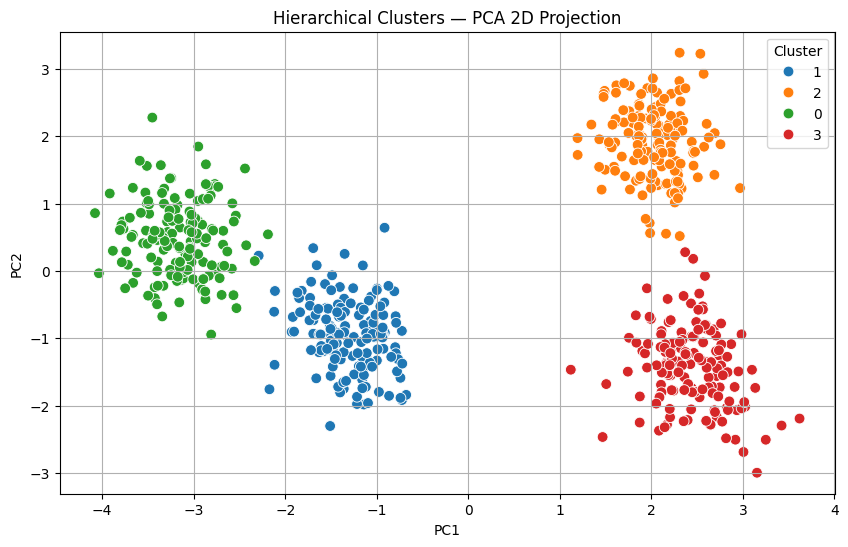

In [14]:
plot_hierarchical = pca_df.copy()

plot_hierarchical["Cluster"] = (
    hierarchical_labels.astype(str)
)

plt.figure(figsize=(10,6))

sns.scatterplot(
    data=plot_hierarchical,
    x="PC1",
    y="PC2",
    hue="Cluster",
    palette="tab10",
    s=60
)

plt.title(
    "Hierarchical Clusters — PCA 2D Projection"
)

plt.grid(True)
plt.show()


## 13. Clustering Comparison

In [15]:
comparison = pd.DataFrame({
    "Method": [
        "K-Means",
        "Hierarchical"
    ],
    "Clusters": [
        len(np.unique(kmeans_labels)),
        len(np.unique(hierarchical_labels))
    ],
    "Silhouette Score": [
        kmeans_score,
        hierarchical_silhouette
    ]
})

display(
    comparison.round(4)
)

if dbscan_silhouette is not None:

    print(
        "DBSCAN silhouette score:",
        round(dbscan_silhouette, 4)
    )


,Method,Clusters,Silhouette Score
0,K-Means,4,0.5197
1,Hierarchical,4,0.5197


DBSCAN silhouette score: 0.5411


# Findings

1. The numerical features were standardized before dimensionality reduction and clustering.
2. PCA reduced the high-dimensional feature space while providing explained-variance information.
3. The scree plot and cumulative explained variance plot were generated to support PCA component selection.
4. K-Means was evaluated using both the Elbow Method and Silhouette Score.
5. DBSCAN was applied as a density-based clustering method and potential noise observations were identified.
6. Hierarchical clustering was applied as an additional unsupervised approach.
7. PCA 2D projections were used to visually inspect the discovered cluster structures.

**Important:** The dataset is synthetic and the findings demonstrate the analytical workflow rather than describing a real-world population.
